# Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(), logging.FileHandler("eda.log")]
)
logger = logging.getLogger("rossmann-eda")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

logger.info("Libraries imported and logger initialized.")


2026-08-09 21:54:38,421 | INFO | Libraries imported and logger initialized.


# Load Dataset

In [2]:
logger.info("Loading train, test and store datasets...")

train = pd.read_csv("train.csv", dtype={"StateHoliday": str}, low_memory=False)
test  = pd.read_csv("test.csv",  dtype={"StateHoliday": str})
store = pd.read_csv("store.csv")

train["Date"] = pd.to_datetime(train["Date"], format="%Y-%m-%d")
test["Date"]  = pd.to_datetime(test["Date"],  format="%d-%m-%Y")

logger.info(f"train shape: {train.shape}, test shape: {test.shape}, store shape: {store.shape}")
train.head()


2026-08-09 21:54:38,442 | INFO | Loading train, test and store datasets...
2026-08-09 21:54:40,824 | INFO | train shape: (1017209, 9), test shape: (41088, 8), store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


# Cleaning

In [3]:
logger.info("Cleaning store.csv...")
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())
store["CompetitionOpenSinceMonth"] = store["CompetitionOpenSinceMonth"].fillna(0)
store["CompetitionOpenSinceYear"] = store["CompetitionOpenSinceYear"].fillna(0)
store["Promo2SinceWeek"] = store["Promo2SinceWeek"].fillna(0)
store["Promo2SinceYear"] = store["Promo2SinceYear"].fillna(0)
store["PromoInterval"] = store["PromoInterval"].fillna("None")

logger.info("Cleaning test.csv Open column...")
test["Open"] = test["Open"].fillna(1)

# Outlier check: Sales==0 while Open==1 (data-entry anomalies) 
anomaly = train[(train["Open"] == 1) & (train["Sales"] == 0)]
logger.info(f"Rows with Open=1 but Sales=0: {len(anomaly)}")

#  Outlier check: extreme sales values on open days (IQR method) 
open_sales = train.loc[train["Open"] == 1, "Sales"]
q1, q3 = open_sales.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = (open_sales > upper).sum()
logger.info(f"Sales upper IQR bound: {upper:.0f} | extreme high-sales days: {n_outliers} ({n_outliers/len(open_sales)*100:.2f}%)")

print(f"Anomalies (Open=1, Sales=0): {len(anomaly)}")
print(f"High-sales outliers (IQR): {n_outliers} ({n_outliers/len(open_sales)*100:.2f}% of open days)")


2026-08-09 21:54:40,878 | INFO | Cleaning store.csv...
2026-08-09 21:54:40,892 | INFO | Cleaning test.csv Open column...
2026-08-09 21:54:40,910 | INFO | Rows with Open=1 but Sales=0: 54
2026-08-09 21:54:40,957 | INFO | Sales upper IQR bound: 13612 | extreme high-sales days: 30769 (3.64%)


Anomalies (Open=1, Sales=0): 54
High-sales outliers (IQR): 30769 (3.64% of open days)


In [4]:
before = len(train)
train_clean = train[~((train["Open"] == 1) & (train["Sales"] == 0))].copy()
logger.info(f"Dropped {before - len(train_clean)} anomalous rows. New shape: {train_clean.shape}")

# Also drop closed-store days for sales-behavior analysis (Sales is trivially 0 when closed)
train_open = train_clean[train_clean["Open"] == 1].copy()
print(f"Rows after cleaning: {len(train_clean)} | Open-only rows used for sales analysis: {len(train_open)}")


2026-08-09 21:54:41,128 | INFO | Dropped 54 anomalous rows. New shape: (1017155, 9)


Rows after cleaning: 1017155 | Open-only rows used for sales analysis: 844338


# Merge

In [5]:
df = train_open.merge(store, on="Store", how="left")
test_m = test.merge(store, on="Store", how="left")

# Basic date-derived features (useful for the EDA questions below)
for d in (df, test_m):
    d["Year"] = d["Date"].dt.year
    d["Month"] = d["Date"].dt.month
    d["WeekOfYear"] = d["Date"].dt.isocalendar().week.astype(int)
    d["IsWeekend"] = d["DayOfWeek"].isin([6, 7]).astype(int)

logger.info(f"Merged dataframe shape: {df.shape}")
df.head()


2026-08-09 21:54:42,686 | INFO | Merged dataframe shape: (844338, 22)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,WeekOfYear,IsWeekend
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,0.0,None,2015,7,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,0.0,None,2015,7,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,0.0,None,2015,7,31,0


In [6]:
df.shape

(844338, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  object        
 10  Assortment                 844338 non-null  object        
 11  CompetitionDistance        844338 non-null  float64 

# EDA

# Are promotions distributed similarly between train and test?

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,5)

         train_%     test_%
Promo                      
0      61.848548  60.416667
1      38.151452  39.583333


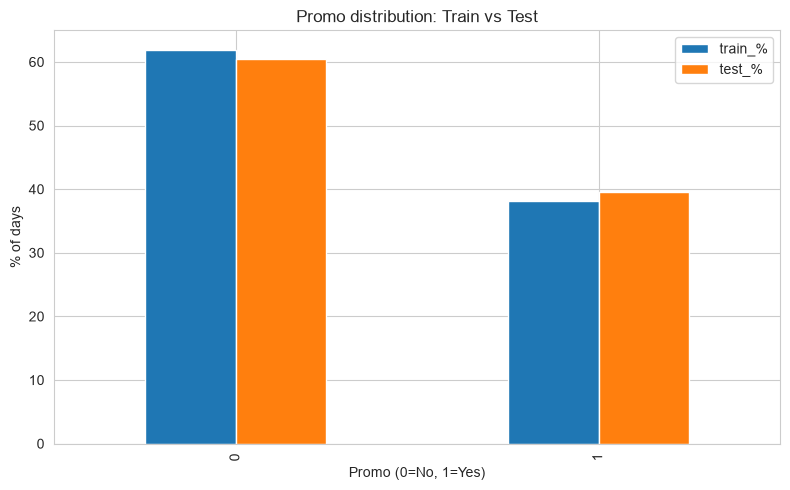

In [9]:
promo_compare = pd.DataFrame({
    "train_%": train["Promo"].value_counts(normalize=True) * 100,
    "test_%":  test["Promo"].value_counts(normalize=True) * 100
})
print(promo_compare)

fig, ax = plt.subplots()
promo_compare.plot(kind="bar", ax=ax)
ax.set_title("Promo distribution: Train vs Test")
ax.set_xlabel("Promo (0=No, 1=Yes)")
ax.set_ylabel("% of days")
plt.tight_layout()
plt.show()


# Sales behaviour before, during and after (state) holidays

Normal day            6953.960229
Day before holiday    8681.958567
Holiday               8808.631868
Day after holiday     8823.329670
dtype: float64


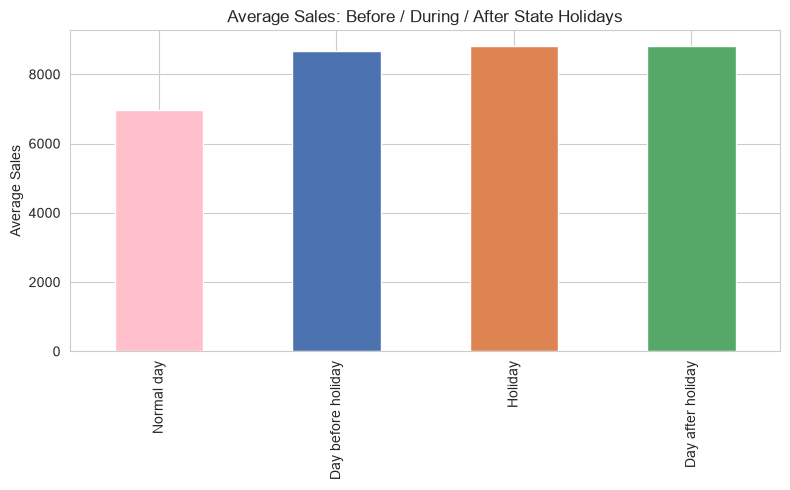

In [10]:
df_sorted = df.sort_values(["Store", "Date"]).copy()
df_sorted["IsStateHoliday"] = (df_sorted["StateHoliday"] != "0").astype(int)

# For each store, flag the day immediately before/after a holiday
df_sorted["NextDayHoliday"] = df_sorted.groupby("Store")["IsStateHoliday"].shift(-1)
df_sorted["PrevDayHoliday"] = df_sorted.groupby("Store")["IsStateHoliday"].shift(1)

before_h = df_sorted.loc[df_sorted["NextDayHoliday"] == 1, "Sales"].mean()
during_h = df_sorted.loc[df_sorted["IsStateHoliday"] == 1, "Sales"].mean()
after_h  = df_sorted.loc[df_sorted["PrevDayHoliday"] == 1, "Sales"].mean()
normal   = df_sorted.loc[df_sorted["IsStateHoliday"] == 0, "Sales"].mean()

comp = pd.Series({"Normal day": normal, "Day before holiday": before_h,
                   "Holiday": during_h, "Day after holiday": after_h})
print(comp)

fig, ax = plt.subplots()
comp.plot(kind="bar", ax=ax, color=["pink","#4C72B0","#DD8452","#55A868"])
ax.set_title("Average Sales: Before / During / After State Holidays")
ax.set_ylabel("Average Sales")
plt.tight_layout()
plt.show()


#  Seasonal purchase behaviour (Christmas, Easter, etc.)

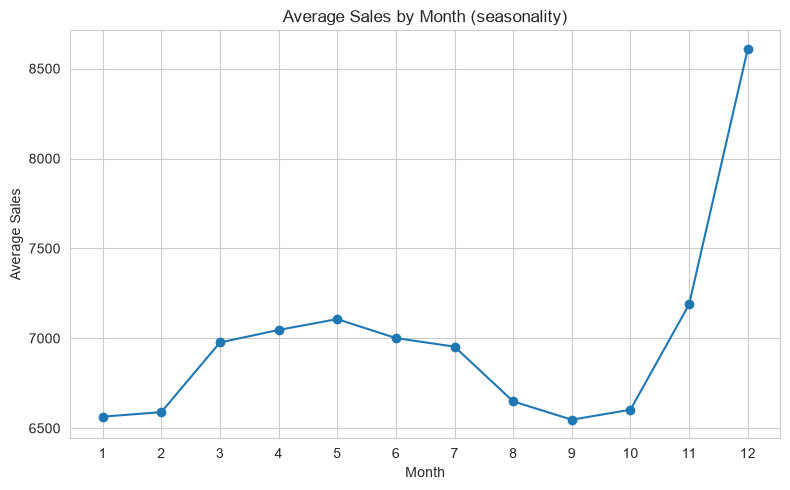

Month
12    8608.956661
11    7188.554250
5     7106.808038
4     7046.659509
6     7001.402127
3     6976.817749
7     6953.575827
8     6649.229053
10    6602.967255
2     6589.494012
1     6564.298651
9     6547.469104
Name: Sales, dtype: float64


In [11]:
monthly = df.groupby("Month")["Sales"].mean()

fig, ax = plt.subplots()
monthly.plot(kind="line", marker="o", ax=ax)
ax.set_title("Average Sales by Month (seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Sales")
ax.set_xticks(range(1,13))
plt.tight_layout()
plt.show()

print(monthly.sort_values(ascending=False))


#  Correlation between Sales and Customers

Correlation(Sales, Customers) = 0.824


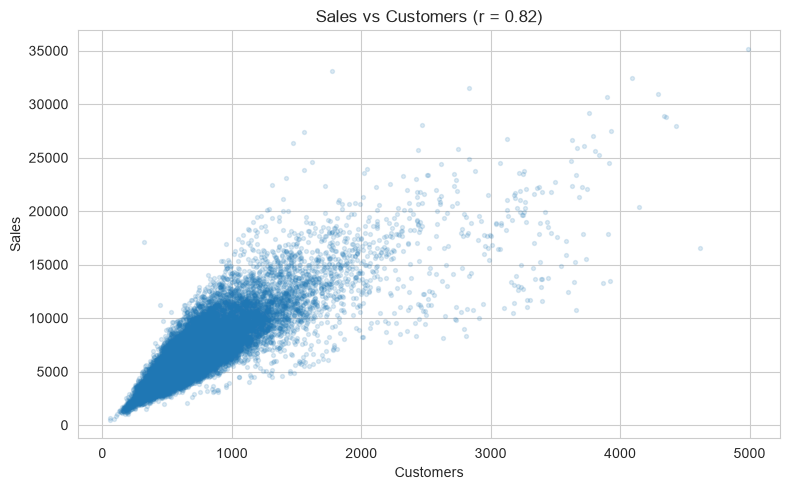

In [12]:
corr = df["Sales"].corr(df["Customers"])
print(f"Correlation(Sales, Customers) = {corr:.3f}")

fig, ax = plt.subplots()
sample = df.sample(20000, random_state=42)
ax.scatter(sample["Customers"], sample["Sales"], alpha=0.15, s=8)
ax.set_xlabel("Customers")
ax.set_ylabel("Sales")
ax.set_title(f"Sales vs Customers (r = {corr:.2f})")
plt.tight_layout()
plt.show()


#   How does Promo affect Sales and Customers?

             Sales   Customers  Sales_per_Customer
Promo                                             
0      5929.826183  696.906080            8.508788
1      8228.739731  844.481433            9.744133


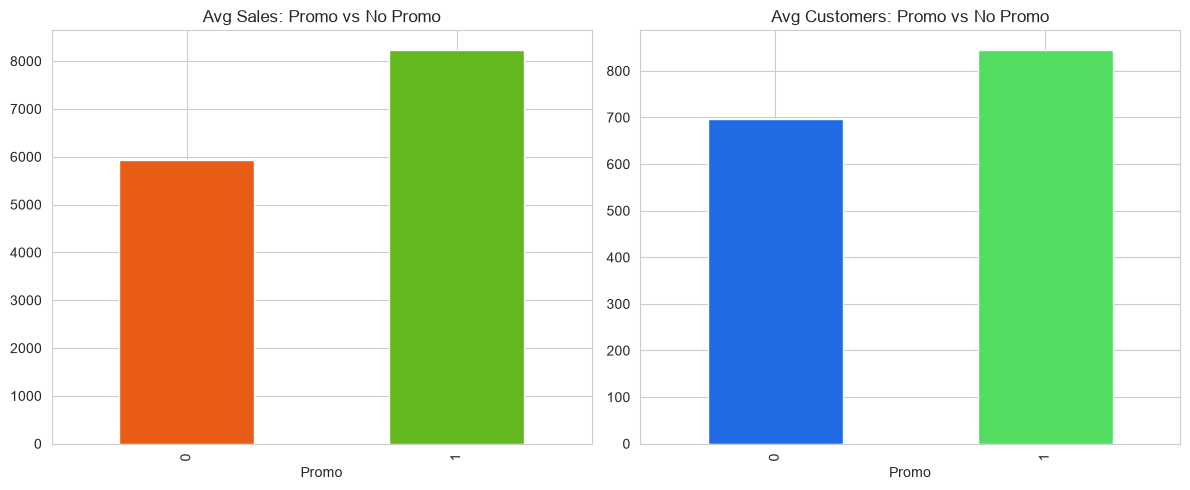

In [13]:
promo_effect = df.groupby("Promo")[["Sales", "Customers"]].mean()
promo_effect["Sales_per_Customer"] = promo_effect["Sales"] / promo_effect["Customers"]
print(promo_effect)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
df.groupby("Promo")["Sales"].mean().plot(kind="bar", ax=axes[0], color=["#E95C15","#64B81F"])
axes[0].set_title("Avg Sales: Promo vs No Promo")
df.groupby("Promo")["Customers"].mean().plot(kind="bar", ax=axes[1], color=["#206BE3","#52DD60"])
axes[1].set_title("Avg Customers: Promo vs No Promo")
plt.tight_layout()
plt.show()


#  Which stores benefit most from promos? (candidates for expanded promo deployment)

Promo            0             1    Uplift_%
Store                                       
198    1753.461538   4294.725212  144.928396
607    2551.573427   5542.971671  117.237396
543    1868.129930   3926.065714  110.160206
575    3614.405172   7586.112727  109.885510
693    4577.874710   9107.817143   98.952958
271    5452.700935  10746.485795   97.085553
552    5412.452436  10565.745714   95.211798
96     3638.345794   7047.616477   93.703866
635    4159.048951   8048.373219   93.514751
489    5143.058275   9950.413105   93.472688


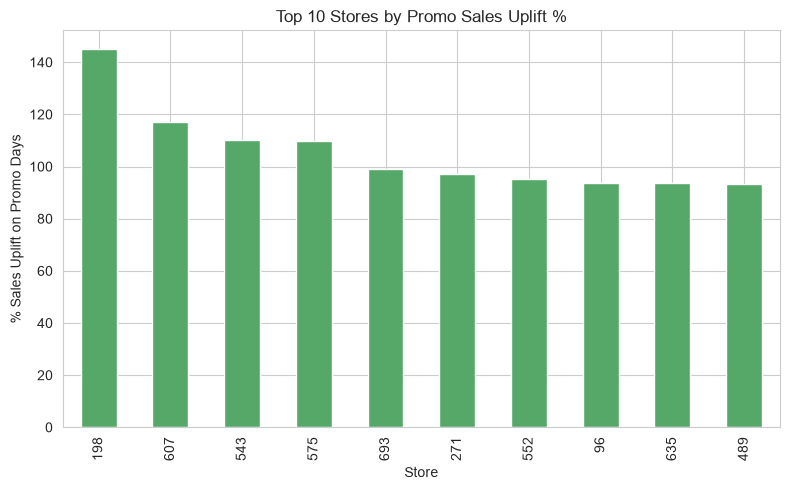

In [14]:
store_promo_uplift = (
    df.groupby(["Store","Promo"])["Sales"].mean().unstack()
)
store_promo_uplift["Uplift_%"] = (store_promo_uplift[1] - store_promo_uplift[0]) / store_promo_uplift[0] * 100
top_uplift = store_promo_uplift.sort_values("Uplift_%", ascending=False).head(10)
print(top_uplift)

fig, ax = plt.subplots()
top_uplift["Uplift_%"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Top 10 Stores by Promo Sales Uplift %")
ax.set_ylabel("% Sales Uplift on Promo Days")
plt.tight_layout()
plt.show()


#  Store open/close trends by day of week

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64


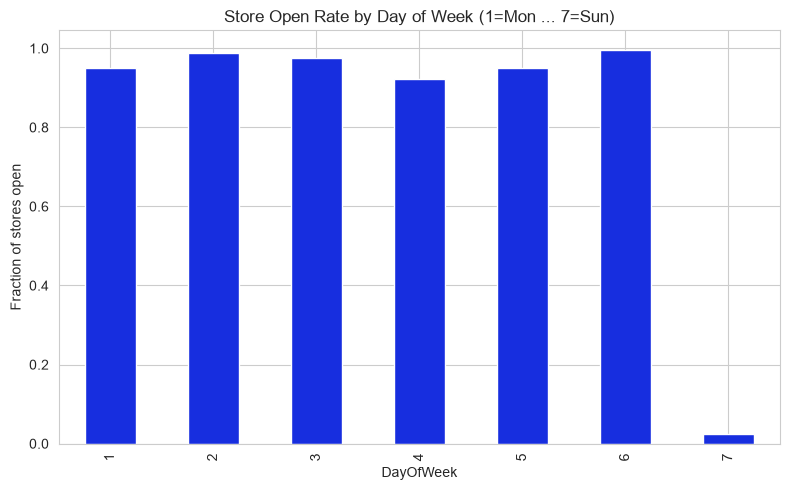

In [24]:
open_rate = train.groupby("DayOfWeek")["Open"].mean()
print(open_rate)

fig, ax = plt.subplots()
open_rate.plot(kind="bar", ax=ax, color="#172EDF")
ax.set_title("Store Open Rate by Day of Week (1=Mon ... 7=Sun)")
ax.set_ylabel("Fraction of stores open")
plt.tight_layout()
plt.show()


# Stores open on all weekdays: does it affect weekend sales?

In [16]:
# Identify stores that are open every day of the Mon-Sat week (DayOfWeek 1-6) historically
weekday_open = train_clean[train_clean["DayOfWeek"].between(1,6)]
open_all_week = weekday_open.groupby("Store")["Open"].mean()
always_open_stores = open_all_week[open_all_week == 1].index

sunday_sales = train_clean[train_clean["DayOfWeek"] == 7]
sunday_sales_always = sunday_sales[sunday_sales["Store"].isin(always_open_stores)]["Sales"].mean()
sunday_sales_others  = sunday_sales[~sunday_sales["Store"].isin(always_open_stores)]["Sales"].mean()

print(f"Stores open every weekday (Mon-Sat): {len(always_open_stores)} / {train_clean['Store'].nunique()}")
print(f"Avg Sunday sales - 'always open' stores: {sunday_sales_always:.0f}")
print(f"Avg Sunday sales - other stores: {sunday_sales_others:.0f}")


Stores open every weekday (Mon-Sat): 10 / 1115
Avg Sunday sales - 'always open' stores: 13249
Avg Sunday sales - other stores: 82


#  Does Assortment type affect Sales?

Assortment
b    8642.503594
c    7300.843547
a    6621.523057
Name: Sales, dtype: float64


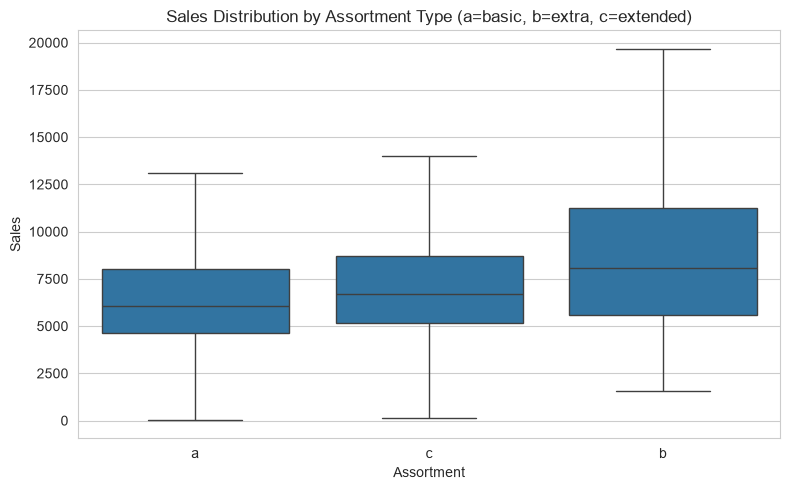

In [17]:
assortment_sales = df.groupby("Assortment")["Sales"].mean().sort_values(ascending=False)
print(assortment_sales)

fig, ax = plt.subplots()
sns.boxplot(data=df, x="Assortment", y="Sales", showfliers=False, ax=ax)
ax.set_title("Sales Distribution by Assortment Type (a=basic, b=extra, c=extended)")
plt.tight_layout()
plt.show()


#  Does distance to nearest competitor affect Sales?

CompDistBin
<500m     7610.892543
500-1k    6676.701732
1k-5k     6827.418000
5k-10k    6742.643204
>10k      6825.048140
Name: Sales, dtype: float64


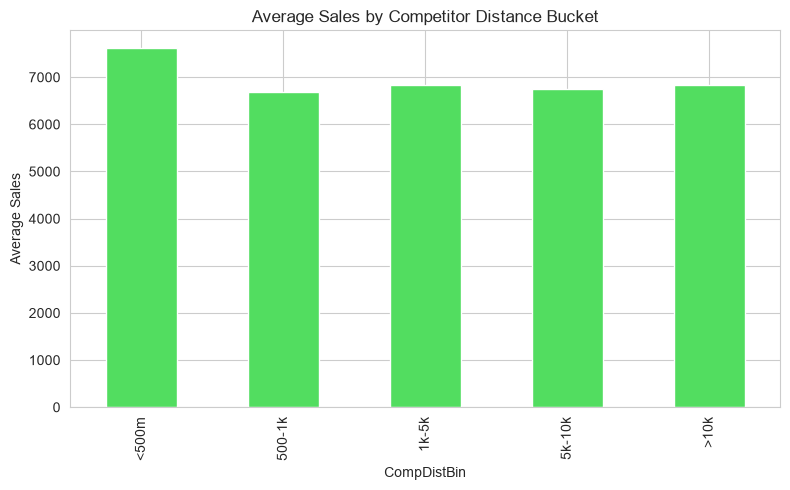

Correlation(CompetitionDistance, Sales) = -0.036


In [18]:
df["CompDistBin"] = pd.cut(df["CompetitionDistance"],
                            bins=[0,500,1000,5000,10000,100000],
                            labels=["<500m","500-1k","1k-5k","5k-10k",">10k"])
comp_sales = df.groupby("CompDistBin", observed=True)["Sales"].mean()
print(comp_sales)

fig, ax = plt.subplots()
comp_sales.plot(kind="bar", ax=ax, color="#52DD60")
ax.set_title("Average Sales by Competitor Distance Bucket")
ax.set_ylabel("Average Sales")
plt.tight_layout()
plt.show()

corr_dist = df["CompetitionDistance"].corr(df["Sales"])
print(f"Correlation(CompetitionDistance, Sales) = {corr_dist:.3f}")


#  Effect of a new/reopened competitor

Stores whose competitor opened DURING the observed period: 188


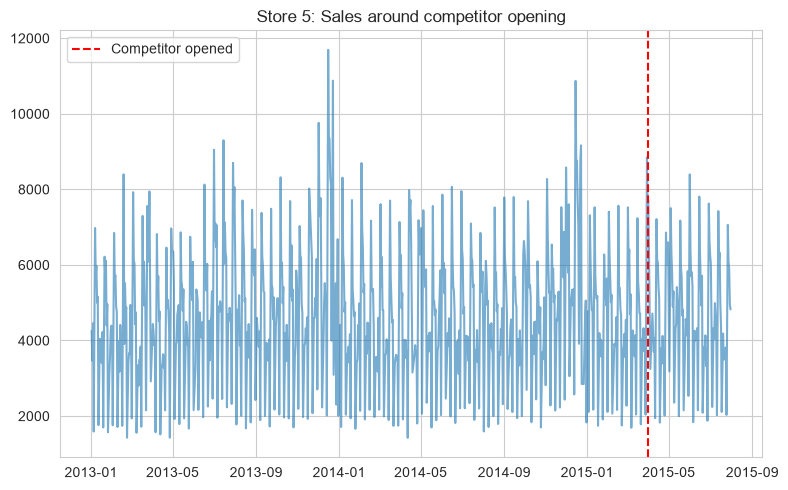

In [19]:
# Stores with a known CompetitionOpenSince date can be checked for a sales shift around that date.
known_comp = store[(store["CompetitionOpenSinceYear"] > 0)].copy()
known_comp["CompOpenDate"] = pd.to_datetime(
    dict(year=known_comp["CompetitionOpenSinceYear"].astype(int),
         month=known_comp["CompetitionOpenSinceMonth"].astype(int), day=1),
    errors="coerce"
)
# focus on competitor openings that fall inside our train date range, so we can see before/after
in_range = known_comp[known_comp["CompOpenDate"].between(train["Date"].min(), train["Date"].max())]
print(f"Stores whose competitor opened DURING the observed period: {len(in_range)}")

sample_store = in_range["Store"].iloc[0]
open_date = in_range.loc[in_range["Store"] == sample_store, "CompOpenDate"].iloc[0]
s_hist = df[df["Store"] == sample_store].sort_values("Date")

fig, ax = plt.subplots()
ax.plot(s_hist["Date"], s_hist["Sales"], alpha=0.6)
ax.axvline(open_date, color="red", linestyle="--", label="Competitor opened")
ax.set_title(f"Store {sample_store}: Sales around competitor opening")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
# # Insights -

# - Data was clean overall; `Open=1 & Sales=0` anomalies were removed; store metadata NAs were structural (non-participation in Promo2) and filled accordingly.
# - Promo distribution is stable across train/test — no distribution shift concern.
# - Strong day-before/holiday/day-after sales pattern → engineer holiday-proximity features.
# - Clear seasonality (December, Easter) → engineer month/seasonal features.
# - Sales↔Customers highly correlated but not 1:1 → basket-size (Sales/Customer) is a useful derived feature.
# - Promos increase both traffic and basket size, but uplift is store-specific → engineer store-level historical promo uplift.
# - Assortment 'b' and proximity to competitors show non-obvious effects — likely confounded with store locality (urban vs. rural), worth a locality/city-center proxy feature if available.
